Iniciando 10 validaciones independientes con corrección de balanceo...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid f

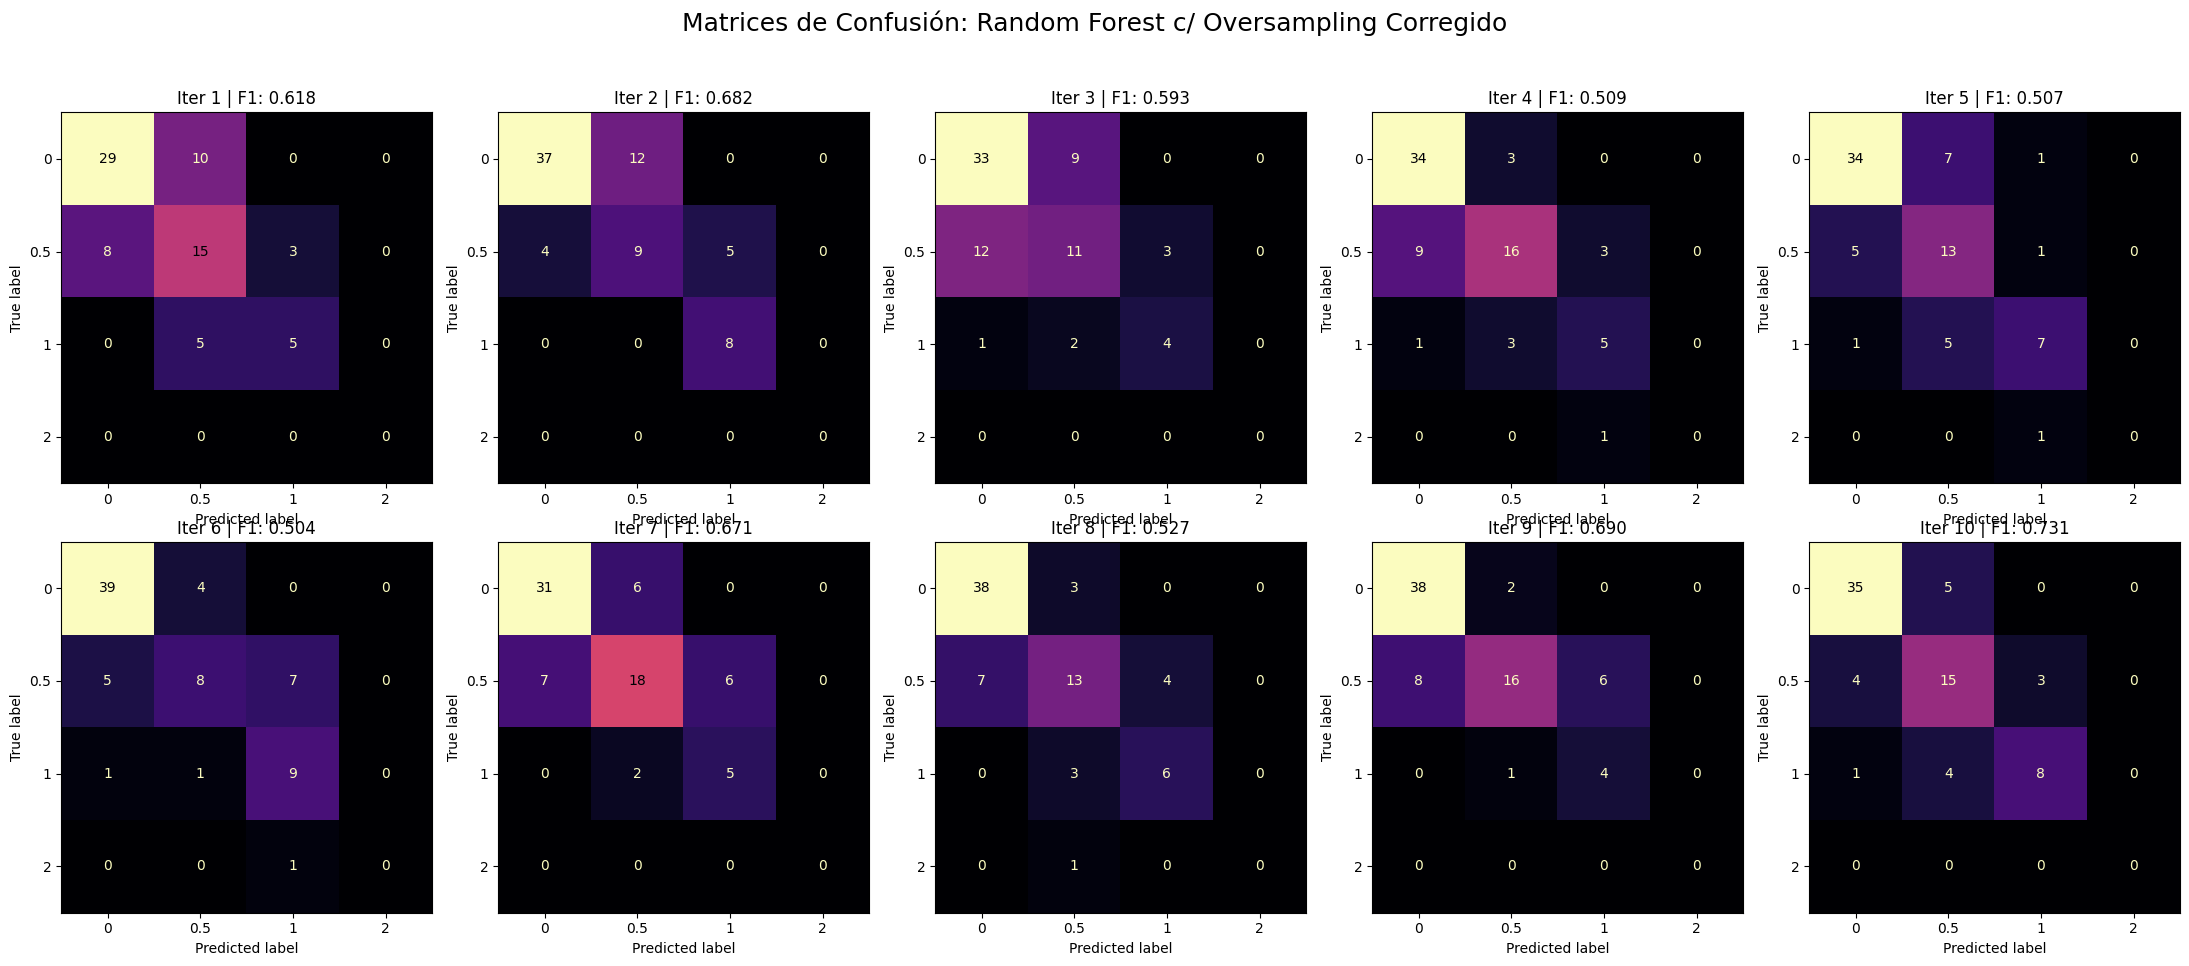


Métrica Final (10 iteraciones)           | Promedio ± DE            
-----------------------------------------------------------------
ACC                                      | 0.7240 ± 0.0434
PREC                                     | 0.6025 ± 0.0802
REC                                      | 0.6233 ± 0.0984
F1                                       | 0.6032 ± 0.0831
AUC                                      | 0.8018 ± 0.0535


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# 1. Carga y Preparación de Datos (Foco Longitudinal: 373 ejemplos [1])
df_longi = pd.read_csv('oasis_longitudinal.csv')

# Selección de atributos clínicos según la guía [2]
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df_longi[features]
y = df_longi['CDR'].astype(str) # 4 clases: 0.0, 0.5, 1.0, 2.0 [1]
clases_str = ['0.0', '0.5', '1.0', '2.0']

# Imputación de valores faltantes (SES y MMSE) usando la mediana [2]
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

# Grid para las 10 matrices de confusión (Requisito de estilo)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

# Almacenamiento de métricas para reporte final (Sección 12 de la guía [3])
metrics_results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}

print("Iniciando 10 validaciones independientes con corrección de balanceo...")

# 2. Diseño Experimental: 10 Validaciones Independientes 80/20 [3]
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # --- PASO DE BALANCEO (Solo en entrenamiento para evitar data leakage [2]) ---
    train_df = pd.DataFrame(X_train, columns=features)
    train_df['target'] = y_train.values
    
    # SOLUCIÓN DEFINITIVA: Usamos len() para asegurar un número entero, no una tupla
    n_clase_mayoritaria = len(train_df[train_df['target'] == '0.0'])
    
    list_resampled = []
    for c in clases_str:
        df_clase_actual = train_df[train_df['target'] == c]
        
        # Realizamos el sobre-muestreo (oversampling) [4]
        # Si la clase tiene pocos ejemplos (como CDR 2.0), se replican hasta alcanzar n_clase_mayoritaria
        df_upsampled = resample(df_clase_actual, 
                                replace=True, 
                                n_samples=n_clase_mayoritaria, 
                                random_state=42)
        list_resampled.append(df_upsampled)
    
    # Consolidamos el set de entrenamiento balanceado
    df_train_bal = pd.concat(list_resampled)
    X_train_bal = df_train_bal.drop('target', axis=1)
    y_train_bal = df_train_bal['target']
    # ----------------------------------------------------------------------------

    # 3. Entrenamiento (Random Forest - Recomendado para OASIS [5])
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train_bal, y_train_bal)
    
    # 4. Predicción y Cálculo de Métricas (Sobre el test original desbalanceado [2])
    y_pred = rf.predict(X_test)
    y_proba = rf.predict_proba(X_test)
    
    metrics_results['acc'].append(accuracy_score(y_test, y_pred))
    metrics_results['prec'].append(precision_score(y_test, y_pred, average='macro', zero_division=0))
    metrics_results['rec'].append(recall_score(y_test, y_pred, average='macro', zero_division=0))
    metrics_results['f1'].append(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    # Manejo de AUC multiclase ante el desbalance extremo [Turno anterior]
    y_test_bin = label_binarize(y_test, classes=clases_str)
    try:
        metrics_results['auc'].append(roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro'))
    except ValueError:
        metrics_results['auc'].append(np.nan)

    # 5. Generación de Matriz de Confusión por iteración [6]
    cm = confusion_matrix(y_test, y_pred, labels=clases_str)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='magma', colorbar=False)
    axes[i].set_title(f"Iter {i+1} | F1: {metrics_results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión: Random Forest c/ Oversampling Corregido", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 6. Reporte Estadístico Final (Media ± DE [7])
print("\n" + "="*65)
print(f"{'Métrica Final (10 iteraciones)':<40} | {'Promedio ± DE':<25}")
print("-" * 65)
for m in metrics_results:
    val_mean = np.nanmean(metrics_results[m])
    val_std = np.nanstd(metrics_results[m])
    print(f"{m.upper():<40} | {val_mean:.4f} ± {val_std:.4f}")
print("="*65)

Calculando curvas de complejidad...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have val

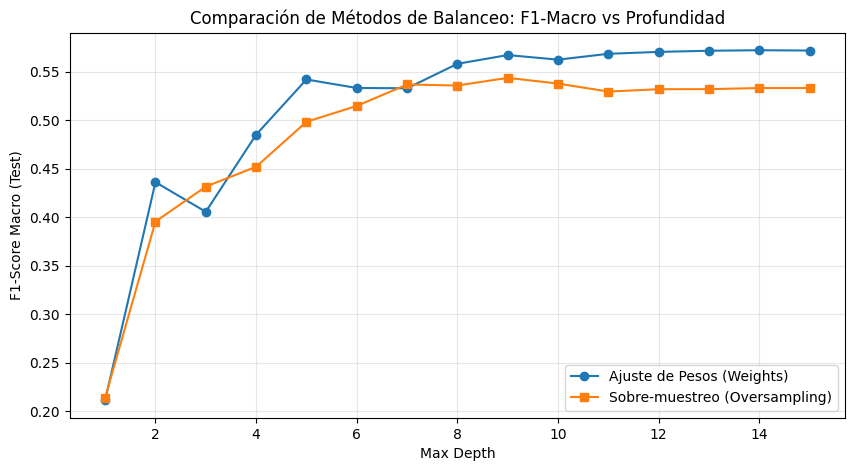

La profundidad óptima detectada es: 14


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Carga y pre-procesamiento del dataset longitudinal
df = pd.read_csv('oasis_longitudinal.csv')
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features]
y = df['CDR'].astype(str) # 4 clases: '0.0', '0.5', '1.0', '2.0'

# Imputación de nulos (SES y MMSE)
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

# 2. Búsqueda de profundidad óptima para ambos métodos
depths = range(1, 16)
scores_weight = []
scores_oversample = []

print("Calculando curvas de complejidad...")

for d in depths:
    f1_w, f1_o = [], []
    for i in range(10): # 10 Validaciones independientes 80/20
        xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
        
        # MÉTODO 1: Ajuste de Pesos
        dt_w = DecisionTreeClassifier(max_depth=d, class_weight='balanced', random_state=42)
        dt_w.fit(xt, yt)
        f1_w.append(f1_score(yv, dt_w.predict(xv), average='macro', zero_division=0))
        
        # MÉTODO 2: Oversampling (Sobre-muestreo manual)
        train_df = pd.DataFrame(xt, columns=features)
        train_df['target'] = yt.values
        n_max = len(train_df[train_df['target'] == '0.0'])
        
        balanced_list = []
        for c in ['0.0', '0.5', '1.0', '2.0']:
            c_df = train_df[train_df['target'] == c]
            c_up = resample(c_df, replace=True, n_samples=n_max, random_state=42)
            balanced_list.append(c_up)
        
        df_bal = pd.concat(balanced_list)
        dt_o = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt_o.fit(df_bal.drop('target', axis=1), df_bal['target'])
        f1_o.append(f1_score(yv, dt_o.predict(xv), average='macro', zero_division=0))
        
    scores_weight.append(np.mean(f1_w))
    scores_oversample.append(np.mean(f1_o))

# Visualización para selección de hiperparámetro
plt.figure(figsize=(10, 5))
plt.plot(depths, scores_weight, label='Ajuste de Pesos (Weights)', marker='o')
plt.plot(depths, scores_oversample, label='Sobre-muestreo (Oversampling)', marker='s')
plt.title("Comparación de Métodos de Balanceo: F1-Macro vs Profundidad")
plt.xlabel("Max Depth")
plt.ylabel("F1-Score Macro (Test)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

opt_depth = depths[np.argmax(scores_weight)]
print(f"La profundidad óptima detectada es: {opt_depth}")

Generando Grid: Ajuste de Pesos (Depth 14)...


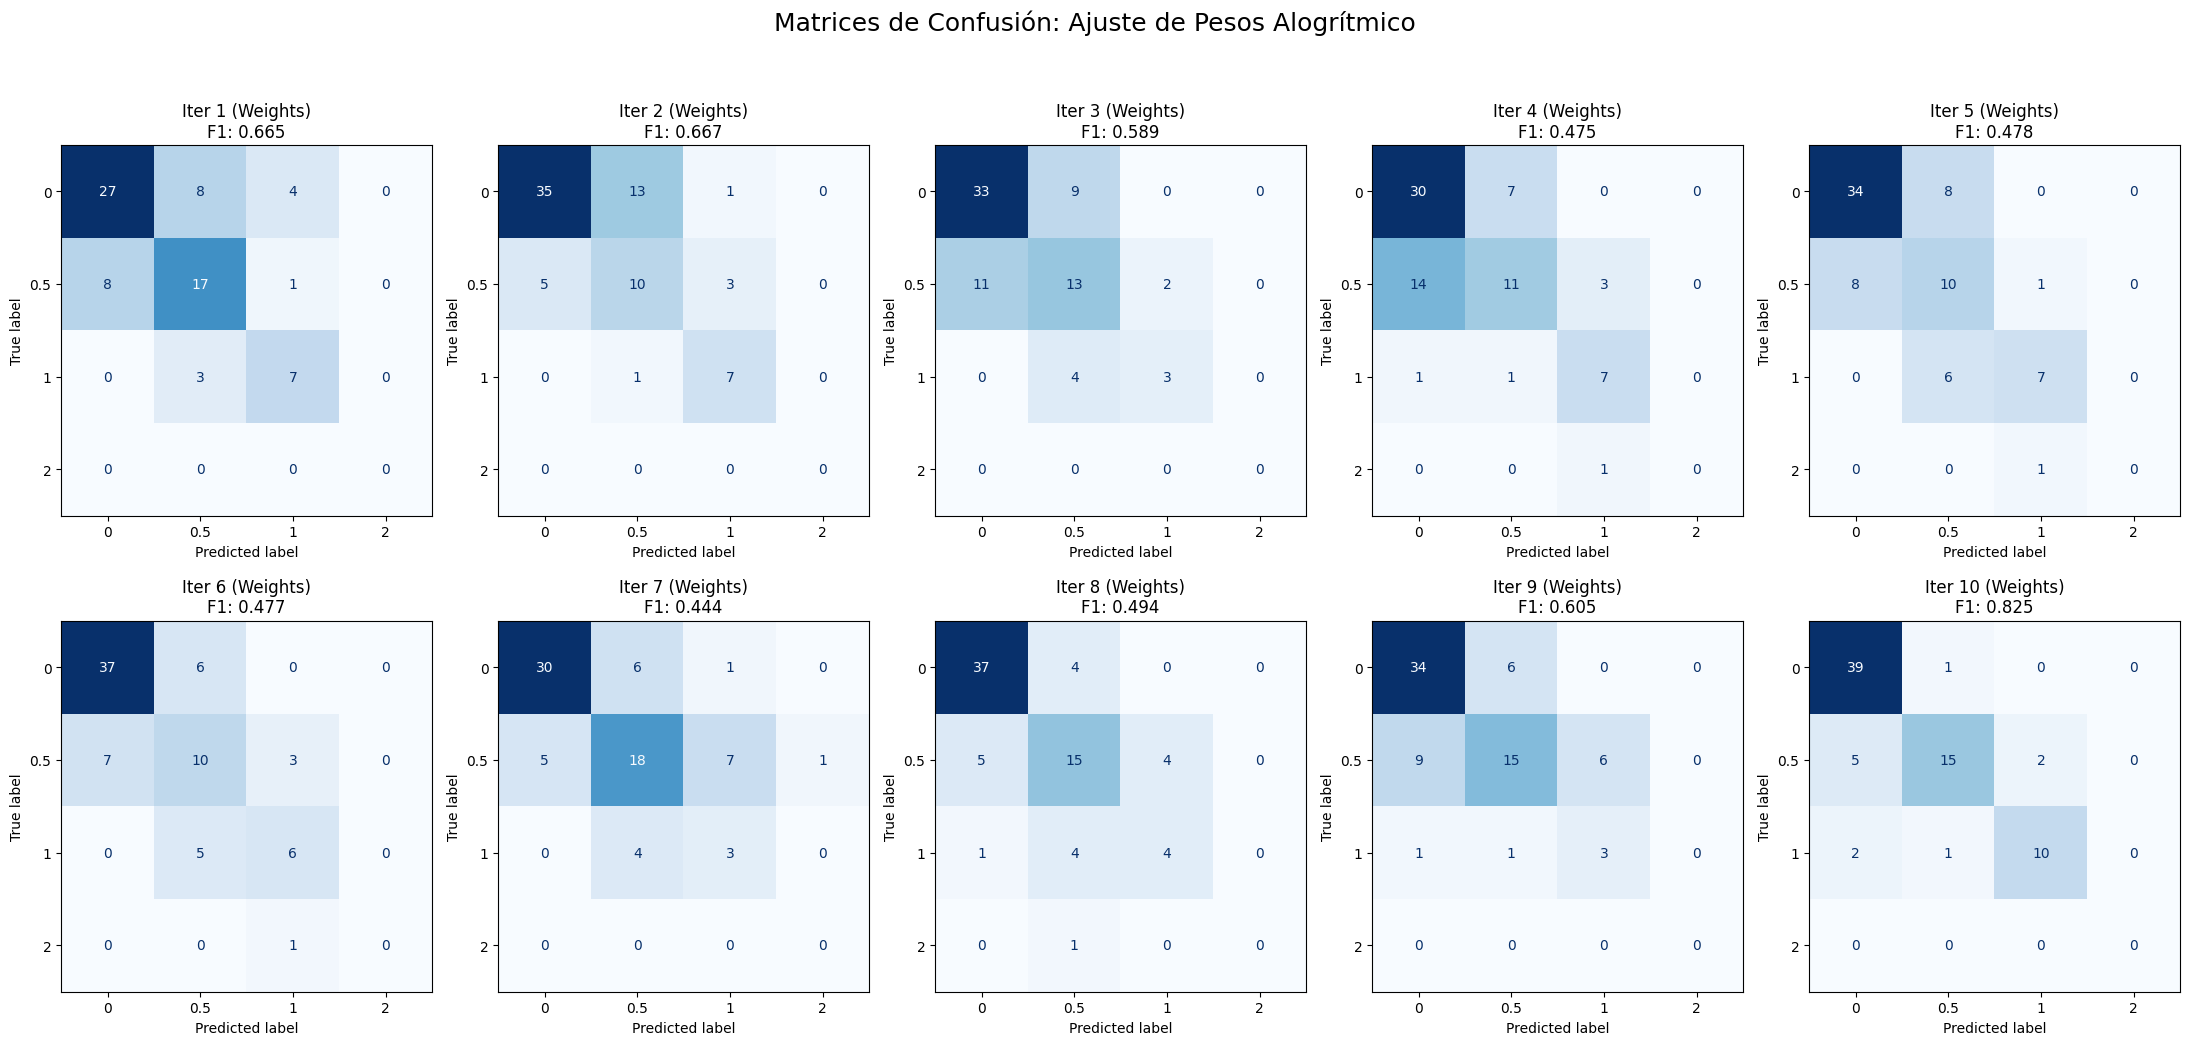

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()
print(f"Generando Grid: Ajuste de Pesos (Depth {opt_depth})...")

for i in range(10):
    xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
    model = DecisionTreeClassifier(max_depth=opt_depth, class_weight='balanced', random_state=42)
    model.fit(xt, yt)
    y_pred = model.predict(xv)
    
    cm = confusion_matrix(yv, y_pred, labels=['0.0', '0.5', '1.0', '2.0'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iter {i+1} (Weights)\nF1: {f1_score(yv, y_pred, average='macro', zero_division=0):.3f}")

plt.suptitle("Matrices de Confusión: Ajuste de Pesos Alogrítmico", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Generando Grid: Oversampling (Depth 14)...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have val

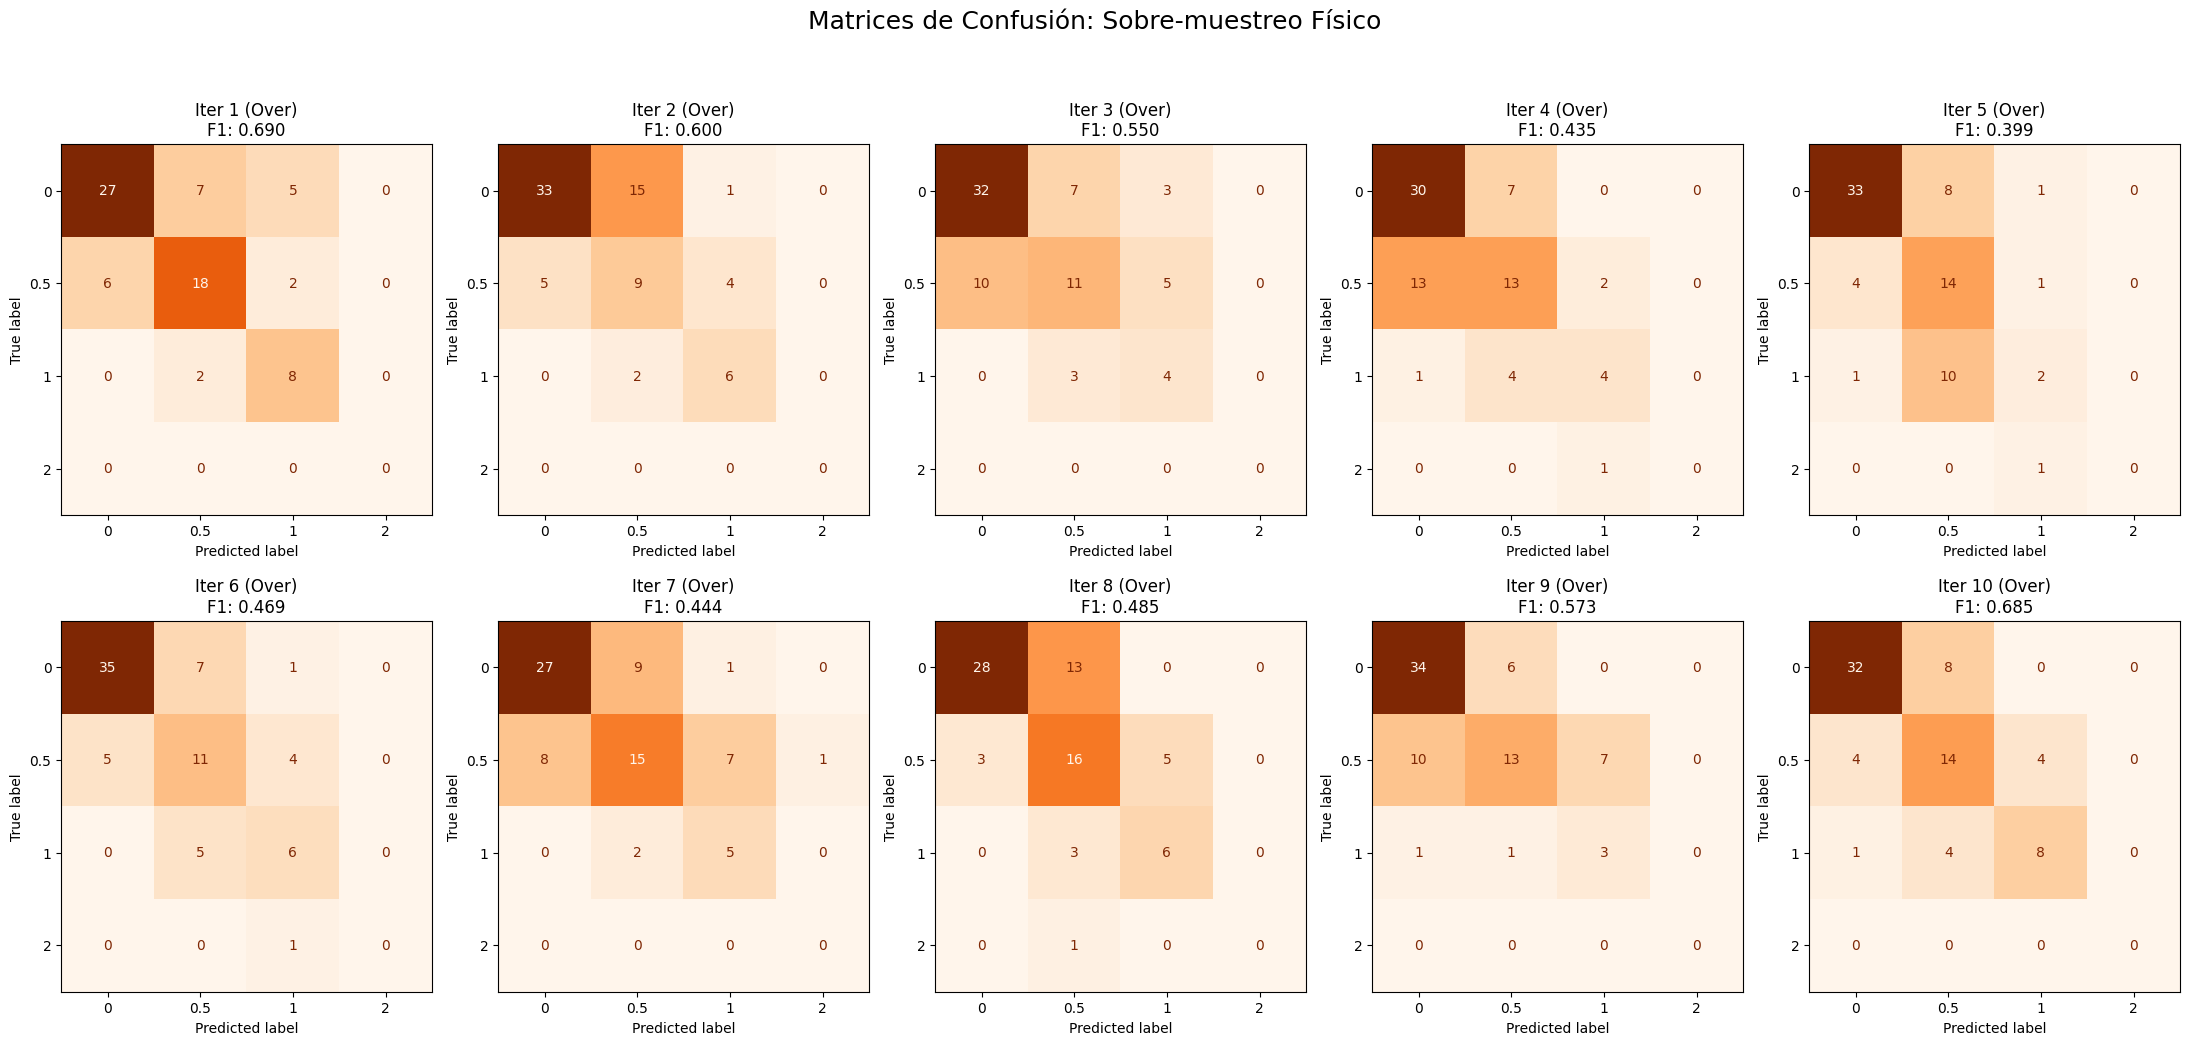

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()
print(f"Generando Grid: Oversampling (Depth {opt_depth})...")

for i in range(10):
    xt, xv, yt, yv = train_test_split(X_prep, y, test_size=0.2, random_state=i)
    
    # Balanceo físico del set de entrenamiento
    t_df = pd.DataFrame(xt, columns=features); t_df['target'] = yt.values
    n_max = len(t_df[t_df['target'] == '0.0'])
    df_bal = pd.concat([resample(t_df[t_df['target'] == c], replace=True, n_samples=n_max, random_state=42) 
                        for c in ['0.0', '0.5', '1.0', '2.0']])
    
    model = DecisionTreeClassifier(max_depth=opt_depth, random_state=42)
    model.fit(df_bal.drop('target', axis=1), df_bal['target'])
    y_pred = model.predict(xv)
    
    cm = confusion_matrix(yv, y_pred, labels=['0.0', '0.5', '1.0', '2.0'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='Oranges', colorbar=False)
    axes[i].set_title(f"Iter {i+1} (Over)\nF1: {f1_score(yv, y_pred, average='macro', zero_division=0):.3f}")

plt.suptitle("Matrices de Confusión: Sobre-muestreo Físico", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Ejecutando 10 validaciones independientes con análisis por clase...


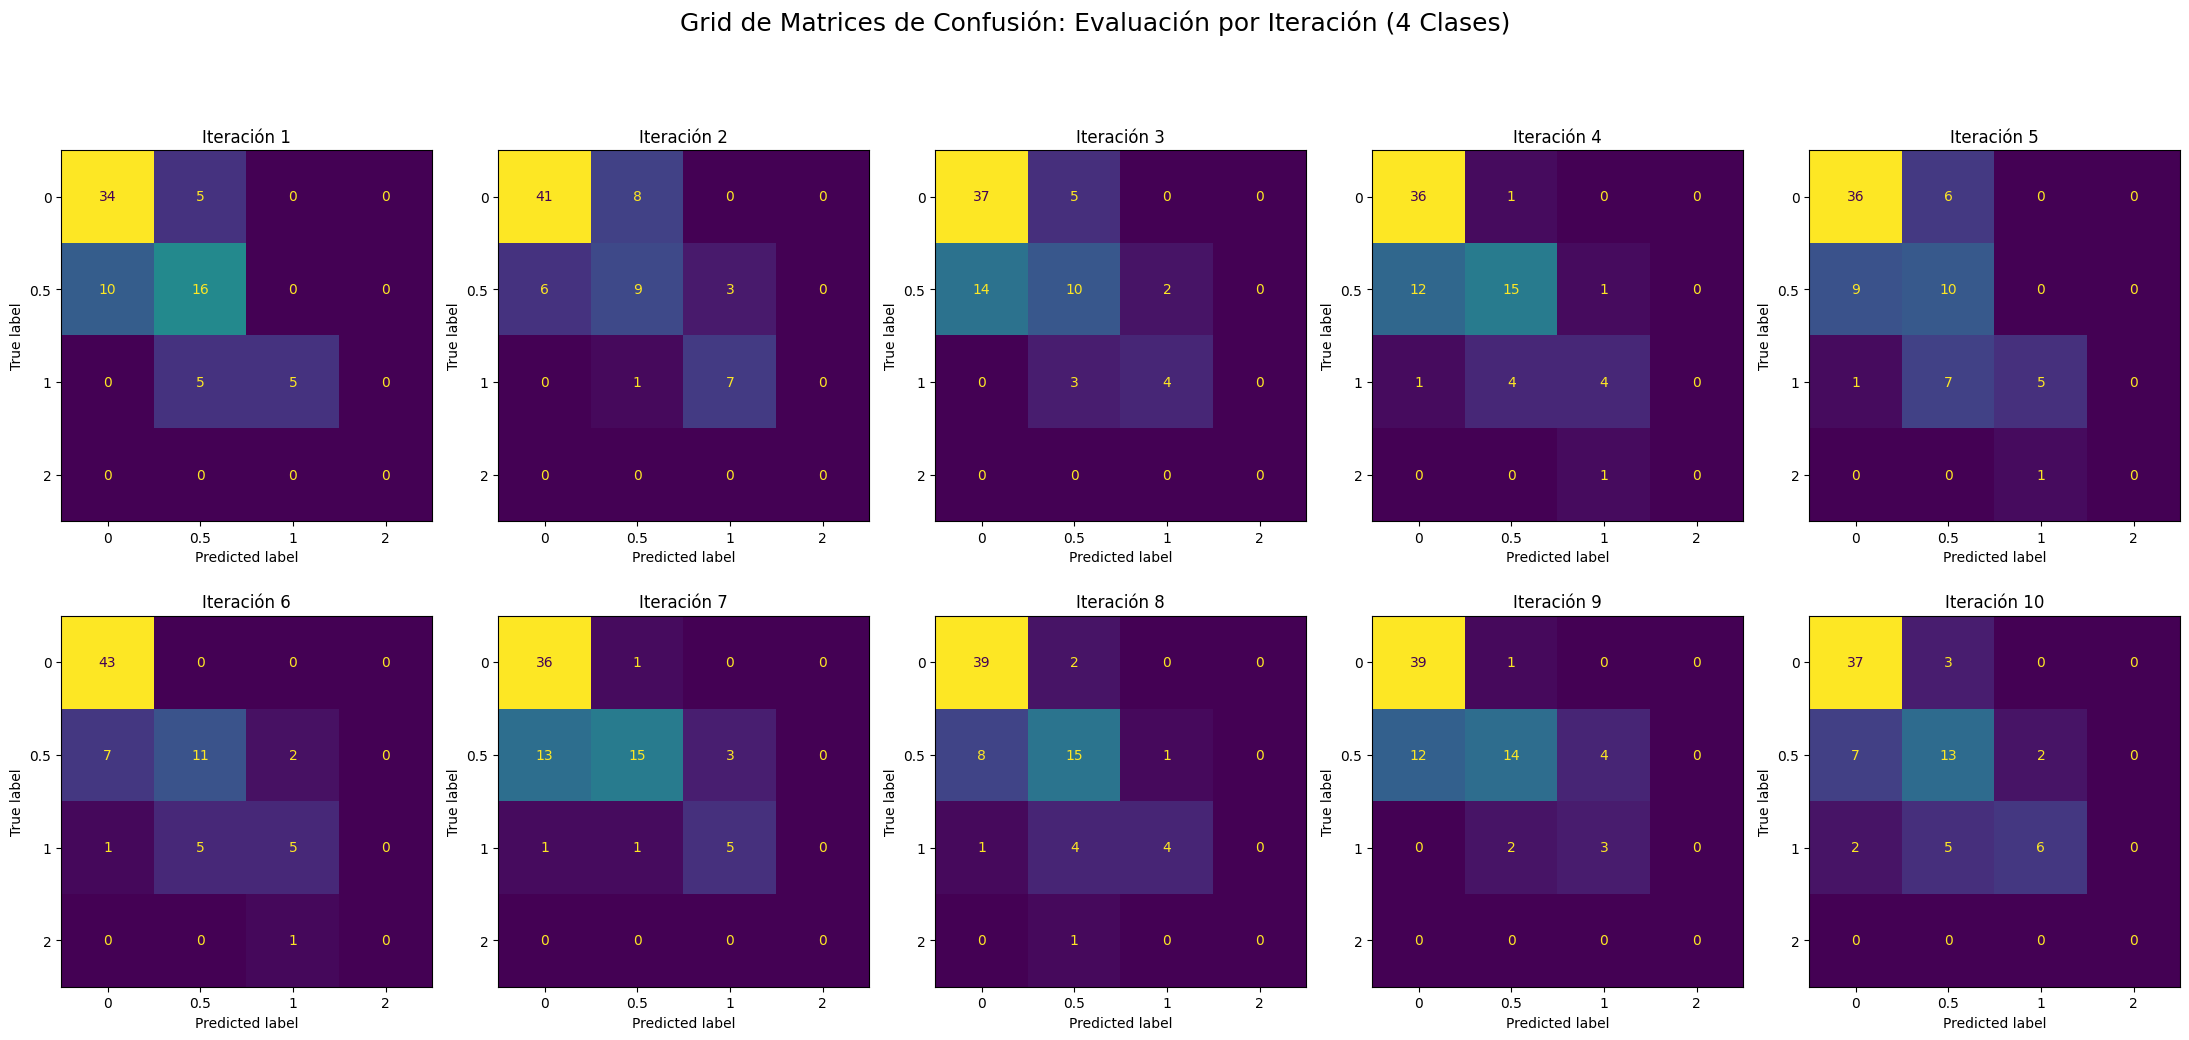


CDR CLASE    | PRECISION    | RECALL       | F1-SCORE    
----------------------------------------------------------------------
0.0          | 0.783±0.05 | 0.924±0.06 | 0.846±0.03
0.5          | 0.655±0.13 | 0.528±0.07 | 0.576±0.07
1.0          | 0.710±0.14 | 0.545±0.14 | 0.596±0.08
2.0          | 0.000±0.00 | 0.000±0.00 | 0.000±0.00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Preparación del Dataset Longitudinal (373 ejemplos)
df_longi = pd.read_csv('oasis_longitudinal.csv')
features = ['Sex', 'Age', 'EDUC', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df_longi[features]
y = df_longi['CDR'].astype(str) # 4 clases: 0.0, 0.5, 1.0, 2.0

# Imputación de nulos (SES y MMSE)
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

# Grid para las 10 matrices de confusión por iteración [Instrucción personalizada]
fig, axes = plt.subplots(2, 5, figsize=(22, 11))
axes = axes.flatten()

# Lista para almacenar los reportes de clasificación de cada iteración
all_reports = []

print("Ejecutando 10 validaciones independientes con análisis por clase...")

for i in range(10):
    # 2. Diseño Experimental: Validación 80/20 independiente [6]
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 3. Modelo con Aprendizaje Sensible al Costo [1, 4]
    # class_weight='balanced' aplica una penalización mayor a errores en clases minoritarias
    rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    
    # 4. Análisis por Clase: Generación del Reporte Detallado [2]
    # Este paso extrae Precision, Recall y F1 para CADA una de las 4 clases
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    all_reports.append(report)
    
    # 5. Visualización: Matriz de Confusión por iteración [2, 7]
    cm = confusion_matrix(y_test, y_pred, labels=['0.0', '0.5', '1.0', '2.0'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['0', '0.5', '1', '2'])
    disp.plot(ax=axes[i], cmap='viridis', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}")

plt.suptitle("Grid de Matrices de Confusión: Evaluación por Iteración (4 Clases)", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 6. Consolidación del Análisis por Clase (Promedio de las 10 iteraciones)
print("\n" + "="*70)
print(f"{'CDR CLASE':<12} | {'PRECISION':<12} | {'RECALL':<12} | {'F1-SCORE':<12}")
print("-" * 70)

for clase in ['0.0', '0.5', '1.0', '2.0']:
    p_list = [r[clase]['precision'] for r in all_reports if clase in r]
    r_list = [r[clase]['recall'] for r in all_reports if clase in r]
    f_list = [r[clase]['f1-score'] for r in all_reports if clase in r]
    
    # Reportamos Media ± DE para cada clase individualmente [6]
    print(f"{clase:<12} | {np.mean(p_list):.3f}±{np.std(p_list):.2f} | "
          f"{np.mean(r_list):.3f}±{np.std(r_list):.2f} | {np.mean(f_list):.3f}±{np.std(f_list):.2f}")
print("="*70)

Iniciando validaciones independientes...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


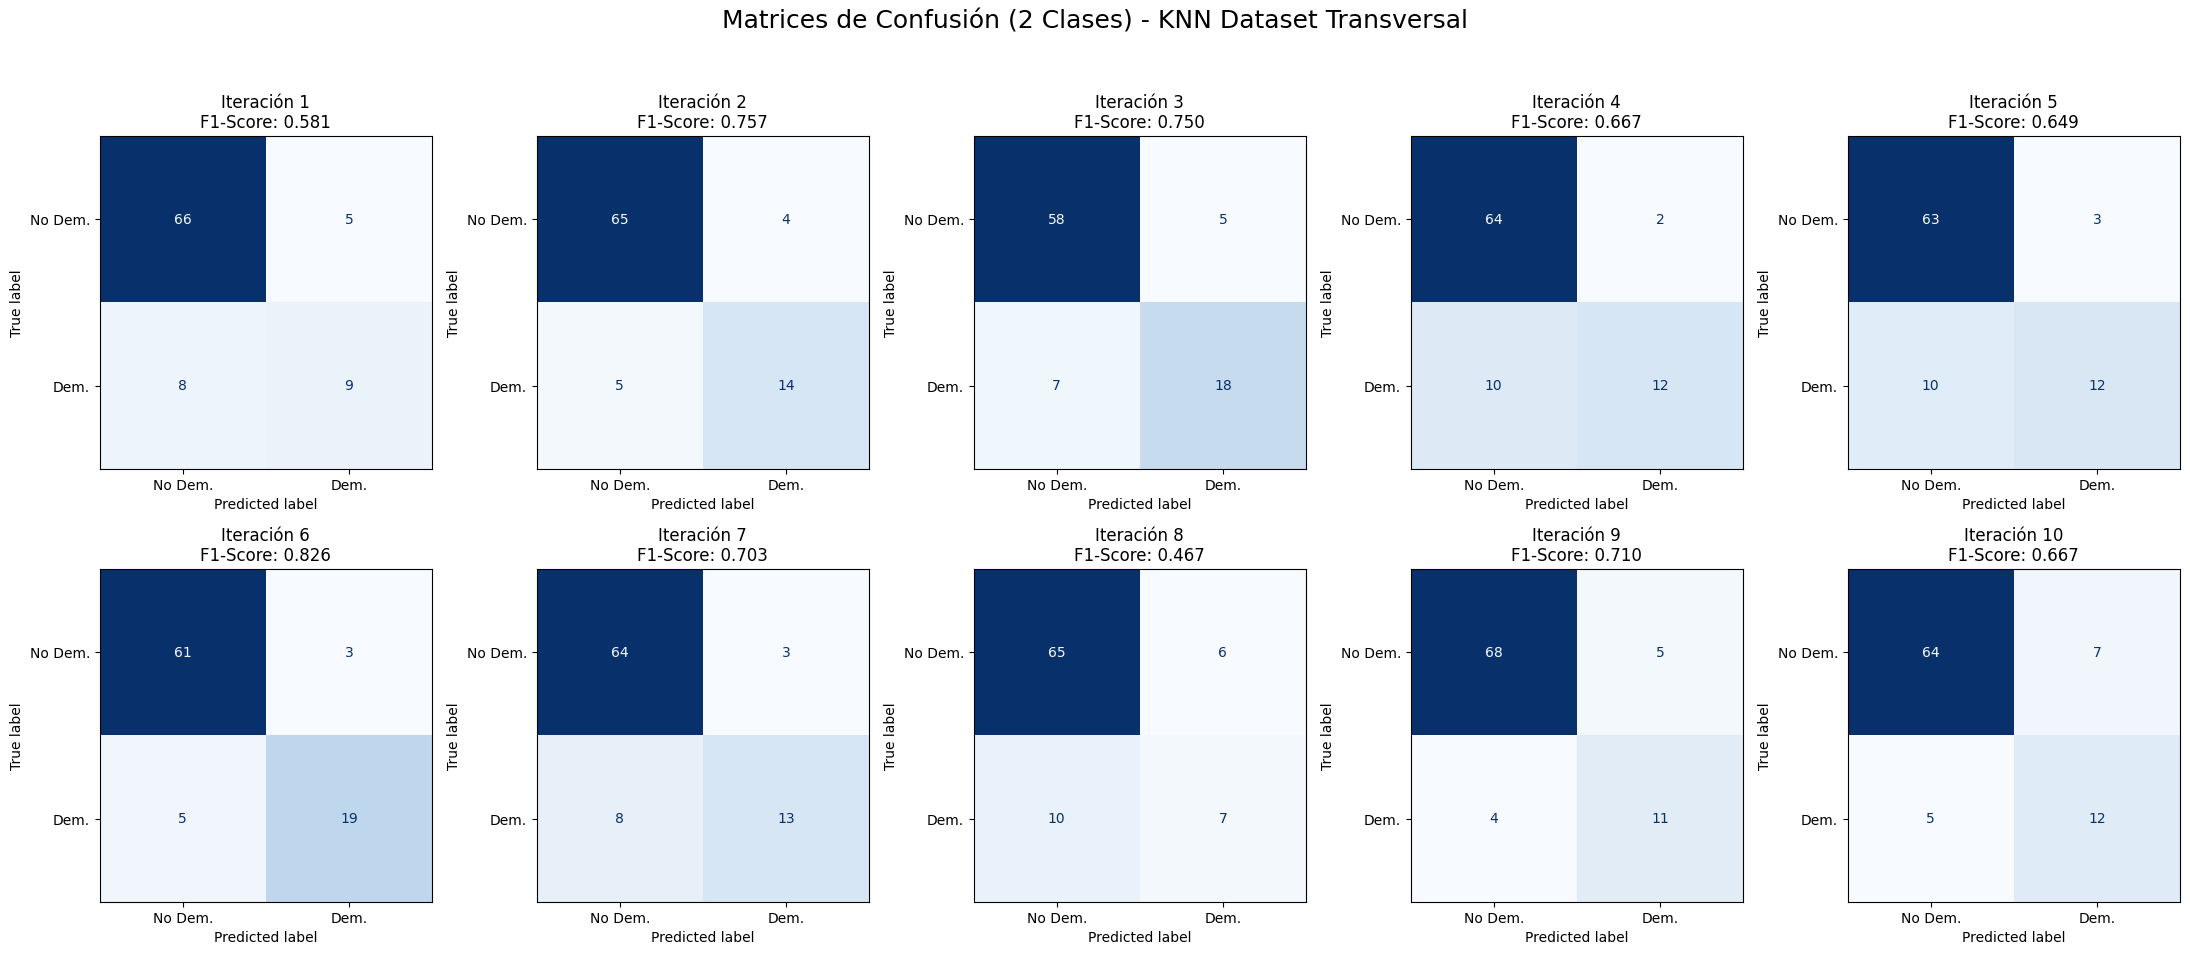


Métrica              | Promedio ± DE (10 iteraciones)
--------------------------------------------------
Accuracy             | 0.8693 ± 0.0255
Precision            | 0.7394 ± 0.1028
Recall               | 0.6339 ± 0.1158
F1-score             | 0.6775 ± 0.0950
AUC                  | 0.9041 ± 0.0383


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)

# 1. Carga y Preparación del Dataset Transversal (oasis_cross-sectional.csv)
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de atributos clínicos y demográficos
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()

# Codificación de Sexo (M=0, F=1)
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- NUEVO LINEAMIENTO: Binarización de CDR (2 Clases) ---
# CDR 0 -> 0 (Non demented), CDR >= 0.5 -> 1 (Demented)
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)

# 2. Tratamiento de Datos Faltantes (Crítico en el set transversal)
# SES, Educ y MMSE tienen valores nulos en este dataset [3, 4]
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# 3. Configuración Experimental (10 Validaciones 80/20)
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Iniciando validaciones independientes...")

for i in range(10):
    # Partición aleatoria única por iteración (Sección 12 de la guía)
    X_train, X_test, y_train, y_test = train_test_split(
        X_imputed, y, test_size=0.2, random_state=i
    )
    
    # 4. Escalamiento Z-score: Requisito de la guía para modelos espaciales [5, 6]
    # Se ajusta en entrenamiento y se aplica en prueba para evitar filtración
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)
    
    # 5. Entrenamiento del Modelo KNN (k=5 por defecto)
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_s, y_train)
    
    # Predicciones
    y_pred = knn.predict(X_test_s)
    y_proba = knn.predict_proba(X_test_s)[:, 1] # Probabilidades para AUC
    
    # 6. Cálculo de Métricas (Sección 13 de la guía)
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 7. Generación de la Matriz de Confusión para cada iteración [Instrucción de estilo]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dem.', 'Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1-Score: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión (2 Clases) - KNN Dataset Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 8. Reporte Final de Desempeño (Media ± DE)
print("\n" + "="*50)
print(f"{'Métrica':<20} | {'Promedio ± DE (10 iteraciones)':<20}")
print("-" * 50)
print(f"{'Accuracy':<20} | {np.mean(results['acc']):.4f} ± {np.std(results['acc']):.4f}")
print(f"{'Precision':<20} | {np.mean(results['prec']):.4f} ± {np.std(results['prec']):.4f}")
print(f"{'Recall':<20} | {np.mean(results['rec']):.4f} ± {np.std(results['rec']):.4f}")
print(f"{'F1-score':<20} | {np.mean(results['f1']):.4f} ± {np.std(results['f1']):.4f}")
print(f"{'AUC':<20} | {np.mean(results['auc']):.4f} ± {np.std(results['auc']):.4f}")
print("="*50)

